# 1- Imports

In [1]:
import os
import kagglehub
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(str(Path("..").resolve()))
from models.GoldPricePredictor import GoldPricePredictor

# 2- Load Data

In [5]:
path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026/versions/2")
df = pd.read_csv(os.path.join(path, "gold_data (1).csv"))

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

print(df.shape)
df.head()

100%|██████████| 1.84M/1.84M [00:01<00:00, 1.48MB/s]

Extracting files...


(6474, 24)


,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,Lag1,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-18,270.299988,270.299988,270.299988,270.299988,0.0,117.330002,1342.130005,33.549999,28.719999,271.100006,...,-0.002951,44.027677,-0.811933,-0.890278,0.078346,277.007532,272.364998,267.722464,1.797421,270.100006
2000-10-19,270.100006,270.100006,270.100006,270.100006,1.0,116.940002,1388.760010,32.950001,25.090000,270.299988,...,-0.000740,43.589968,-0.887787,-0.889780,0.001993,277.016104,272.354999,267.693893,1.683319,271.200012
2000-10-20,271.200012,271.200012,271.200012,271.200012,32.0,117.160004,1396.930054,34.299999,24.240000,270.100006,...,0.004073,46.727258,-0.849350,-0.881694,0.032344,277.007681,272.325000,267.642319,1.641653,270.100006
2000-10-23,271.700012,271.700012,270.100006,270.100006,1.0,117.540001,1395.780029,33.730000,24.690001,271.200012,...,-0.004056,44.086729,-0.897306,-0.884817,-0.012490,276.828986,272.125000,267.421014,1.638679,270.100006
2000-10-24,269.799988,270.100006,269.799988,270.100006,16.0,117.419998,1398.130005,33.369999,24.280001,270.100006,...,0.000000,44.086729,-0.924653,-0.892784,-0.031869,276.643831,271.935001,267.226170,1.543060,266.200012


In [6]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='str')

# 3- Feature Engineering

In [7]:
dow = df.index.dayofweek

df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

month = df.index.month

df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

print(df.shape)

(6474, 28)


# 4- Targets + Features & Labels

In [8]:
HORIZON = 21
df['Target_Direct'] = df["Gold_Close"].shift(-HORIZON)
df = df.dropna(subset=['Target', 'Target_Direct'])

X = df.drop(columns=['Target', 'Target_Direct'])

y_recursive = df['Target']
y_direct = df['Target_Direct']

# 5- Train / Validation / Test Split

In [9]:
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.80)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_r_train = y_recursive.iloc[:train_end]
y_r_val   = y_recursive.iloc[train_end:val_end]
y_r_test  = y_recursive.iloc[val_end:]

y_d_train = y_direct.iloc[:train_end]
y_d_val   = y_direct.iloc[train_end:val_end]
y_d_test  = y_direct.iloc[val_end:]

dates_test = df.index[val_end:]

In [10]:
print("X Train:", X_train.shape)
print("X Validation:", X_val.shape)
print("X Test:", X_test.shape)

print("\nRecursive:")
print("y Train:", y_r_train.shape)
print("y Validation:", y_r_val.shape)
print("y Test:", y_r_test.shape)

print("\nDirect:")
print("y Train:", y_d_train.shape)
print("y Validation:", y_d_val.shape)
print("y Test:", y_d_test.shape)

X Train: (4517, 27)
X Validation: (645, 27)
X Test: (1291, 27)

Recursive:
y Train: (4517,)
y Validation: (645,)
y Test: (1291,)

Direct:
y Train: (4517,)
y Validation: (645,)
y Test: (1291,)


# 6- Scaling

In [11]:
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

# 7- Baselines

In [12]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [13]:
naive_recursive_pred = X_test["Gold_Close"].values

linreg_recursive = LinearRegression()
linreg_recursive.fit(X_train_s, y_r_train)
linreg_recursive_pred = linreg_recursive.predict(X_test_s)

recursive_baselines = {
    "Naive": evaluate_model(y_r_test, naive_recursive_pred),
    "Linear Regression": evaluate_model(y_r_test, linreg_recursive_pred)
}

In [14]:
naive_direct_pred = X_test["Gold_Close"].values

linreg_direct = LinearRegression()
linreg_direct.fit(X_train_s, y_d_train)
linreg_direct_pred = linreg_direct.predict(X_test_s)

direct_baselines = {
    "Naive": evaluate_model(y_d_test, naive_direct_pred),
    "Linear Regression": evaluate_model(y_d_test, linreg_direct_pred)
}

# 8- Train ANN Models

In [15]:
predictor = GoldPricePredictor()

In [16]:
predictor.train_recursive(
    X_train=X_train_s,
    y_train=y_r_train,
    X_val=X_val_s,
    y_val=y_r_val
)

Training Recursive Model
Training artifacts/recursive_gold_model.keras

Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae=24.2474
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae=19.2852
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae=24.2836
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae=20.9332

Best config:
{'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001}
Epoch 1/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 680.1599 - mae: 679.9637 - mse: 677321.8750 - val_loss: 511.1359 - val_mae: 510.8640 - val_mse: 388923.2812 - learning_rate: 0.0010
Epoch 2/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 202.8198

In [17]:
predictor.train_direct(
    X_train=X_train_s,
    y_train=y_d_train,
    X_val=X_val_s,
    y_val=y_d_val
)

Training Direct Model
Training artifacts/direct_gold_model.keras
Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae=56.9304
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae=63.3453
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae=64.2536
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae=63.3796

Best config:
{'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001}
Epoch 1/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 914.5554 - mae: 914.5453 - mse: 1044940.8750 - val_loss: 1355.7920 - val_mae: 1355.7751 - val_mse: 1858990.6250 - learning_rate: 0.0010
Epoch 2/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 427.6944 - 

In [18]:
feature_names = X.columns.tolist()

predictor.recursive_model.features = feature_names
predictor.direct_model.features = feature_names

# 9- Evaluate ANN


Recursive Results
RMSE : 95.756
MAE  : 61.329
R²   : 0.9901


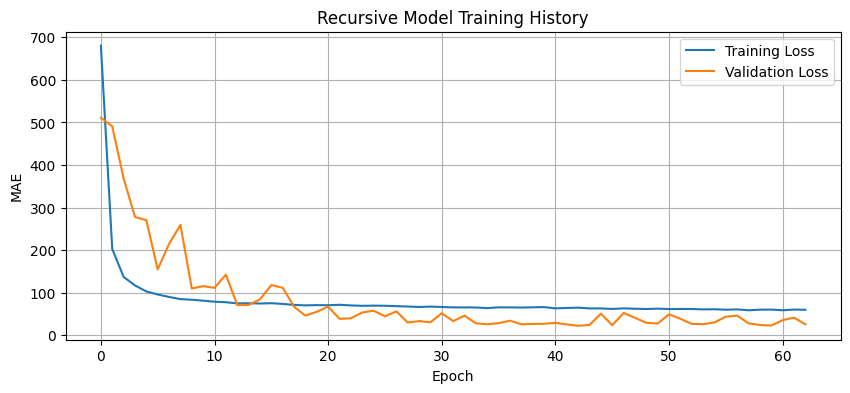


Direct Results
RMSE : 159.673
MAE  : 106.539
R²   : 0.9733


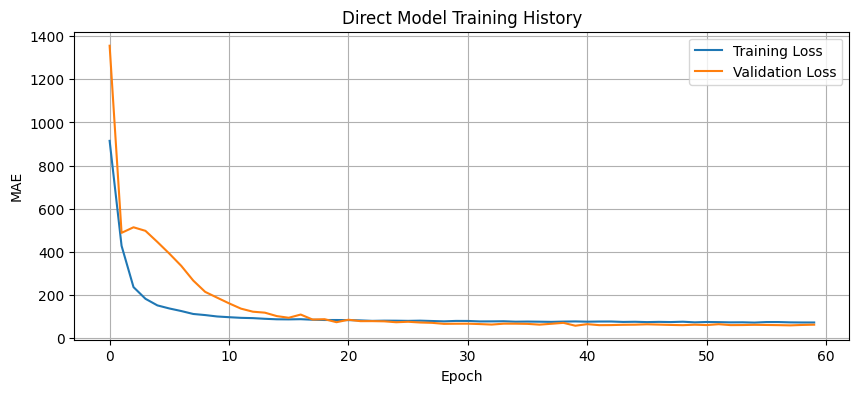

In [19]:
recursive_results = predictor.evaluate_recursive(X_test_s, y_r_test)
direct_results = predictor.evaluate_direct(X_test_s, y_d_test)

# 10- Predictions

In [20]:
recursive_pred = predictor.recursive_model.model.predict(X_test_s, verbose=0).ravel()
direct_pred = predictor.direct_model.model.predict(X_test_s, verbose=0).ravel()

# 11- Comparison Tables + Plots

               Model        MAE       RMSE        R2
0              Naive  23.306661  41.314127  0.998157
1  Linear Regression  23.939303  41.665541  0.998125
2                ANN  61.328631  95.756437  0.990098


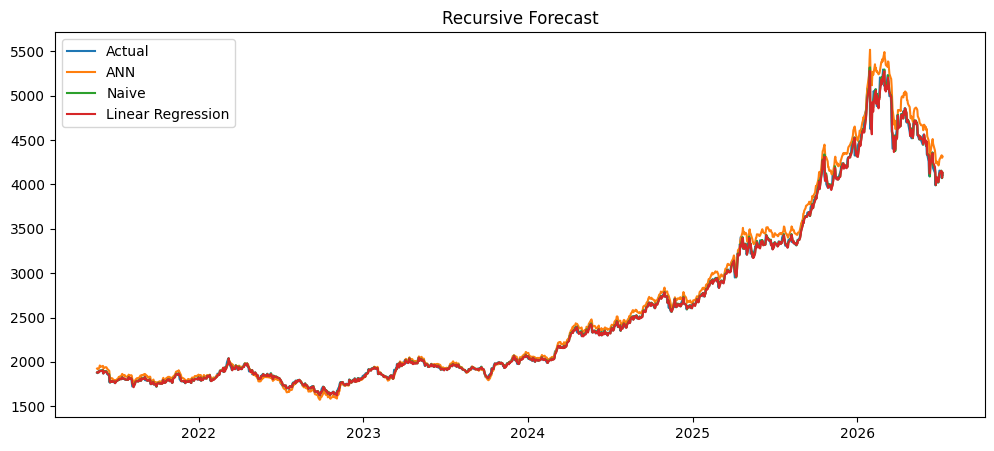

In [21]:
recursive_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Regression",
        "ANN"
    ],
    "MAE": [
        recursive_baselines["Naive"]["MAE"],
        recursive_baselines["Linear Regression"]["MAE"],
        recursive_results["MAE"]
    ],
    "RMSE": [
        recursive_baselines["Naive"]["RMSE"],
        recursive_baselines["Linear Regression"]["RMSE"],
        recursive_results["RMSE"]
    ],
    "R2": [
        recursive_baselines["Naive"]["R2"],
        recursive_baselines["Linear Regression"]["R2"],
        recursive_results["R2"]
    ]
})

print(recursive_comparison)

plt.figure(figsize=(12,5))
plt.plot(dates_test, y_r_test, label="Actual")
plt.plot(dates_test, recursive_pred, label="ANN")
plt.plot(dates_test, naive_recursive_pred, label="Naive")
plt.plot(dates_test, linreg_recursive_pred, label="Linear Regression")
plt.title("Recursive Forecast")
plt.legend()
plt.show()

               Model         MAE        RMSE        R2
0              Naive  107.503407  162.899596  0.972190
1  Linear Regression  132.267523  193.377017  0.960811
2                ANN  106.539120  159.673322  0.973281


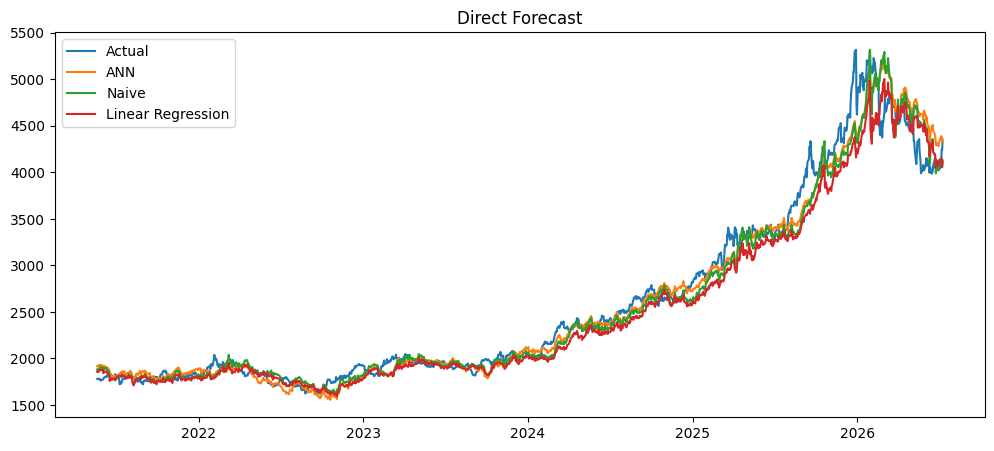

In [22]:
direct_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Regression",
        "ANN"
    ],
    "MAE": [
        direct_baselines["Naive"]["MAE"],
        direct_baselines["Linear Regression"]["MAE"],
        direct_results["MAE"]
    ],
    "RMSE": [
        direct_baselines["Naive"]["RMSE"],
        direct_baselines["Linear Regression"]["RMSE"],
        direct_results["RMSE"]
    ],
    "R2": [
        direct_baselines["Naive"]["R2"],
        direct_baselines["Linear Regression"]["R2"],
        direct_results["R2"]
    ]
})

print(direct_comparison)

plt.figure(figsize=(12,5))
plt.plot(dates_test, y_d_test, label="Actual")
plt.plot(dates_test, direct_pred, label="ANN")
plt.plot(dates_test, naive_direct_pred, label="Naive")
plt.plot(dates_test, linreg_direct_pred, label="Linear Regression")
plt.title("Direct Forecast")
plt.legend()
plt.show()

In [23]:
import joblib

predictor.save_models()

joblib.dump(scaler_X, "artifacts/scaler_X.pkl")
joblib.dump(feature_names,"artifacts/feature_names.pkl")

Models saved successfully.


['artifacts/feature_names.pkl']

In [31]:
result = predictor.predict_gold(
    date="2026-07-01",
    df=df,
    scaler_X=scaler_X,
    days=7
)

7-Day Gold Price Forecast
Lowest predicted 24K price : 136.11
Lowest price date          : 2026-07-02
Highest predicted 24K price: 149.59
Highest price date         : 2026-07-10

21-Day Direct Forecast
Current 24K price/gram: 130.80
Predicted 24K price/gram in ~1 month:
  24K: 138.30
  21K: 121.01
  18K: 103.72

Expected change: +5.73%
Signal: BUY NOW / SELL LATER — price expected to rise
